# Лабораторная работа №4
### Тема: Методы поиска условного экстремума
* **Выполнил:** Бумагин П. В.
* **Группа:** ИУ5-22М
* **Преподаватель:** Гапанюк Ю. Е.

---

### 1. Описание задания
**Цель работы:** 
1. Изучение алгоритмов условной оптимизации (методов последовательной безусловной минимизации).
2. Разработка программ реализации алгоритмов условной оптимизации на языке Python.
3. Нахождение оптимальных решений (минимума) для тестовой функции Розенброка с учетом системы ограничений-неравенств.

**Задачи исследования (Вариант №1):**
* Найти условный минимум целевой функции Розенброка:
  $$f(x_1, x_2) = a(x_1^2 - x_2)^2 + b(x_1 - 1)^2 + f_0$$
  при параметрах: $a = 50$, $b = 2$, $f_0 = 10$.
* Система ограничений-неравенств для Варианта №1:
  1. $g_1(x_1, x_2) = x_1^2 + x_2^2 - 1 \le 0$ (допустимая область внутри единичного круга);
  2. $g_2(x_1, x_2) = -x_1 \le 0 \implies x_1 \ge 0$ (первый квадрант);
  3. $g_3(x_1, x_2) = -x_2 \le 0 \implies x_2 \ge 0$ (первый квадрант).

### 2. Аналитическое исследование условного экстремума

Целевая функция Розенброка:
$$f(x_1, x_2) = 50(x_1^2 - x_2)^2 + 2(x_1 - 1)^2 + 10$$

Точка безусловного глобального минимума данной функции находится в точке $x^* = (1, 1)$, где $f(x^*) = 10$. 
Проверим её на допустимость относительно системы ограничений:
$$g_1(1, 1) = 1^2 + 1^2 - 1 = 1 > 0$$
Условие $g_1(x) \le 0$ нарушено. Следовательно, точка безусловного минимума лежит вне допустимой области, и условный минимум должен находиться строго на границе допустимого множества:
$$g_1(x_1, x_2) = x_1^2 + x_2^2 - 1 = 0 \implies x_2 = \sqrt{1 - x_1^2}$$

Подставим уравнение границы в целевую функцию в первом квадранте ($x_1, x_2 \ge 0$):
$$\phi(x_1) = 50\left(x_1^2 - \sqrt{1 - x_1^2}\right)^2 + 2(x_1 - 1)^2 + 10$$

Для минимизации этой функции найдем точку, в которой овражный (первый) член обращается в ноль:
$$x_1^2 - \sqrt{1 - x_1^2} = 0 \implies x_1^4 = 1 - x_1^2 \implies x_1^4 + x_1^2 - 1 = 0$$

Вводя замену $u = x_1^2 > 0$, получаем квадратное уравнение:
$$u^2 + u - 1 = 0 \implies u = \frac{-1 + \sqrt{5}}{2} \approx 0.618034 \quad \text{(сопряженное золотое сечение)}$$

Отсюда находим координаты условного минимума:
$$x_1^* = \sqrt{\frac{\sqrt{5} - 1}{2}} \approx 0.786151$$
$$x_2^* = u = \frac{\sqrt{5} - 1}{2} \approx 0.618034$$

Проверим выполнение уравнения границы:
$$(x_1^*)^2 + (x_2^*)^2 = u + u^2 = u(1 + u) = 0.618034 \cdot 1.618034 = 1.0 \quad \text{(точка лежит строго на окружности)}$$

**Точное аналитическое решение задачи условной оптимизации:**
* **Координаты точки условного минимума:** $x^* \approx (0.786151,  0.618034)$
* **Значение целевой функции:** $f(x^*) = 2(x_1^* - 1)^2 + 10 \approx 2(0.786151 - 1)^2 + 10 \approx 10.091461$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt

# Параметры Варианта №1
A = 50.0
B = 2.0
F0 = 10.0

# Целевая функция
def f(x):
    return A * (x[0]**2 - x[1])**2 + B * (x[0] - 1)**2 + F0

# Функции ограничений-неравенств g_i(x) <= 0
def g1(x):
    return x[0]**2 + x[1]**2 - 1.0  # Окружность

def g2(x):
    return -x[0]  # x1 >= 0

def g3(x):
    return -x[1]  # x2 >= 0

# Точное аналитическое решение для сравнения
x_exact = np.array([np.sqrt((np.sqrt(5.0) - 1.0) / 2.0), (np.sqrt(5.0) - 1.0) / 2.0])
f_exact = f(x_exact)
print(f"Точное аналитическое решение: x* = {x_exact}, f(x*) = {f_exact:.8f}")

Точное аналитическое решение: x* = [0.78615138 0.61803399], f(x*) = 10.09146247


### 3. Метод внешних штрафных функций

**Суть метода:**
Переходим от условной задачи к безусловной путем минимизации вспомогательной функции:
$$F(x, r^k) = f(x) + \frac{r^k}{2} \sum_{j=1}^3 \left[ \max(0, g_j(x)) \right]^2$$
где $r^k$ — возрастающий параметр штрафа. Начальная точка поиска выбирается вне допустимой области.

In [3]:
def external_penalty_method(x0, r0=1.0, C=5.0, eps=1e-6, max_iter=30):
    x = np.array(x0, dtype=float)
    r = r0
    history = [x.copy()]
    
    for k in range(max_iter):
        # Вспомогательная штрафная функция
        def objective(x_var):
            penalty = 0.5 * r * (
                max(0, g1(x_var))**2 + 
                max(0, g2(x_var))**2 + 
                max(0, g3(x_var))**2
            )
            return f(x_var) + penalty
        
        # Минимизируем вспомогательную функцию локальным симплекс-методом
        res = opt.minimize(objective, x, method='Nelder-Mead', tol=1e-8)
        x_next = res.x
        history.append(x_next.copy())
        
        # Условие останова: изменение координат и величина самого штрафа малы
        penalty_val = 0.5 * r * (max(0, g1(x_next))**2 + max(0, g2(x_next))**2 + max(0, g3(x_next))**2)
        if np.linalg.norm(x_next - x) < eps and penalty_val < eps:
            break
            
        x = x_next
        r *= C # Увеличиваем штраф за нарушение ограничений
        
    return x, np.array(history)

# Стартуем из точки явно вне допустимой области (единичного круга)
x_start_ext = np.array([1.5, 1.5])
x_opt_ext, path_ext = external_penalty_method(x_start_ext)
print(f"Метод внешних штрафов сошелся к точке: {x_opt_ext} за {len(path_ext)-1} шагов штрафа.")

Метод внешних штрафов сошелся к точке: [0.78719782 0.61670107] за 10 шагов штрафа.


### 4. Метод барьерных функций (внутренних штрафов)

**Суть метода:**
Для поиска решения строго внутри допустимой области к целевой функции добавляется логарифмический барьер:
$$F(x, r^k) = f(x) - r^k \sum_{j=1}^3 \ln(-g_j(x))$$
При приближении к границе изнутри значение барьера стремится к бесконечности. С каждой итерацией параметр $r^k$ уменьшается. Начальная точка обязана быть строго внутри допустимой области.

In [4]:
def barrier_method(x0, r0=1.0, C=5.0, eps=1e-6, max_iter=30):
    x = np.array(x0, dtype=float)
    r = r0
    history = [x.copy()]
    
    for k in range(max_iter):
        # Вспомогательная функция с логарифмическим барьером
        def objective(x_var):
            val_g1 = g1(x_var)
            val_g2 = g2(x_var)
            val_g3 = g3(x_var)
            
            # Если вышли за допустимые границы - возвращаем бесконечный штраф
            if val_g1 >= 0 or val_g2 >= 0 or val_g3 >= 0:
                return 1e20
                
            barrier = - r * (np.log(-val_g1) + np.log(-val_g2) + np.log(-val_g3))
            return f(x_var) + barrier
        
        res = opt.minimize(objective, x, method='Nelder-Mead', tol=1e-8)
        x_next = res.x
        history.append(x_next.copy())
        
        if np.linalg.norm(x_next - x) < eps or r < eps:
            break
            
        x = x_next
        r /= C # Уменьшаем барьерный коэффициент для приближения к границе
        
    return x, np.array(history)

# Стартуем строго изнутри допустимой области (первый квадрант единичного круга)
x_start_bar = np.array([0.2, 0.2])
x_opt_bar, path_bar = barrier_method(x_start_bar)
print(f"Метод барьерных функций сошелся к точке: {x_opt_bar} за {len(path_bar)-1} шагов барьера.")

Метод барьерных функций сошелся к точке: [0.7871969  0.61669317] за 10 шагов барьера.


### 5. Метод модифицированных функций Лагранжа (метод множителей)

**Суть метода:**
Объединяет идеи метода внешних штрафов и классического метода множителей Лагранжа. Позволяет находить точное условное решение без необходимости устремлять штрафной параметр $r^k$ к бесконечности, что снижает овражность вспомогательной функции.
$$L(x, \mu^k, r^k) = f(x) + \frac{1}{2r^k} \sum_{j=1}^3 \left[ \max(0, \mu_j^k + r^k g_j(x))^2 - (\mu_j^k)^2 \right]$$

In [5]:
def augmented_lagrangian_method(x0, mu0=[0.1, 0.1, 0.1], r0=1.0, C=5.0, eps=1e-6, max_iter=30):
    x = np.array(x0, dtype=float)
    mu = np.array(mu0, dtype=float)
    r = r0
    history = [x.copy()]
    
    for k in range(max_iter):
        def objective(x_var):
            penalty = 0.0
            for j, g_func in enumerate([g1, g2, g3]):
                val = g_func(x_var)
                penalty += (max(0, mu[j] + r * val)**2 - mu[j]**2) / (2.0 * r)
            return f(x_var) + penalty
        
        res = opt.minimize(objective, x, method='Nelder-Mead', tol=1e-8)
        x_next = res.x
        history.append(x_next.copy())
        
        # Обновление оценок множителей Лагранжа (шаг Ш.4 алгоритма)
        mu_next = np.zeros_like(mu)
        for j, g_func in enumerate([g1, g2, g3]):
            mu_next[j] = max(0, mu[j] + r * g_func(x_next))
            
        if np.linalg.norm(x_next - x) < eps:
            break
            
        x = x_next
        mu = mu_next
        r *= C
        
    return x, np.array(history)

# Стартуем из внешней точки
x_start_lag = np.array([1.5, 1.5])
x_opt_lag, path_lag = augmented_lagrangian_method(x_start_lag)
print(f"Метод модифицированных функций Лагранжа сошелся к точке: {x_opt_lag} за {len(path_lag)-1} шагов.")

Метод модифицированных функций Лагранжа сошелся к точке: [0.78720008 0.61669821] за 5 шагов.


### 6. Сравнительный анализ точности работы методов

In [6]:
results = [
    {
        "Метод": "Точное аналитическое решение",
        "Найденная точка x*": f"[{x_exact[0]:.6f}, {x_exact[1]:.6f}]",
        "Значение f(x*)": f"{f_exact:.8f}",
        "Кол-во внешних итераций": "-"
    },
    {
        "Метод": "Метод внешних штрафов",
        "Найденная точка x*": f"[{x_opt_ext[0]:.6f}, {x_opt_ext[1]:.6f}]",
        "Значение f(x*)": f"{f(x_opt_ext):.8f}",
        "Кол-во внешних итераций": len(path_ext) - 1
    },
    {
        "Метод": "Метод барьерных функций",
        "Найденная точка x*": f"[{x_opt_bar[0]:.6f}, {x_opt_bar[1]:.6f}]",
        "Значение f(x*)": f"{f(x_opt_bar):.8f}",
        "Кол-во внешних итераций": len(path_bar) - 1
    },
    {
        "Метод": "Модифицированный Лагранж",
        "Найденная точка x*": f"[{x_opt_lag[0]:.6f}, {x_opt_lag[1]:.6f}]",
        "Значение f(x*)": f"{f(x_opt_lag):.8f}",
        "Кол-во внешних итераций": len(path_lag) - 1
    }
]

df_results = pd.DataFrame(results)
df_results

,Метод,Найденная точка x*,Значение f(x*),Кол-во внешних итераций
0,Точное аналитическое решение,"[0.786151, 0.618034]",10.09146247,-
1,Метод внешних штрафов,"[0.787198, 0.616701]",10.09101336,10
2,Метод барьерных функций,"[0.787197, 0.616693]",10.09101607,10
3,Модифицированный Лагранж,"[0.787200, 0.616698]",10.09101335,5


### Визуализация траекторий методов оптимизации

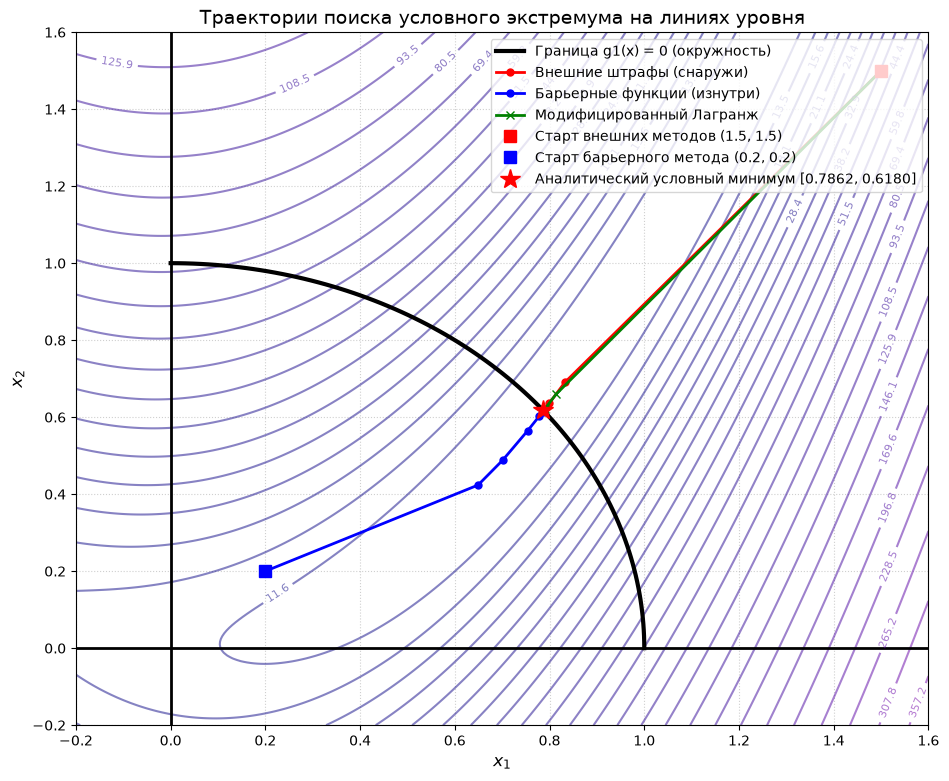

In [8]:
# Построение линий уровня и границ ограничений
x1_vals = np.linspace(-0.2, 1.6, 250)
x2_vals = np.linspace(-0.2, 1.6, 250)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = A * (X1**2 - X2)**2 + B * (X1 - 1)**2 + F0

plt.figure(figsize=(11, 9))

# Отрисовка линий уровня целевой функции Розенброка
contours = plt.contour(X1, X2, Z, levels=np.logspace(1.0, 3.2, 35), cmap='plasma', alpha=0.5)
plt.clabel(contours, inline=True, fontsize=8, fmt='%.1f')

# Отрисовка границы ограничения g1(x) = 0 (дуга единичной окружности)
theta = np.linspace(0, np.pi/2, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=3, label='Граница g1(x) = 0 (окружность)')
plt.axvline(0, color='black', linewidth=2.0)
plt.axhline(0, color='black', linewidth=2.0)

# Отрисовка траекторий движения методов
plt.plot(path_ext[:, 0], path_ext[:, 1], 'r-o', markersize=5, linewidth=2, label='Внешние штрафы (снаружи)')
plt.plot(path_bar[:, 0], path_bar[:, 1], 'b-o', markersize=5, linewidth=2, label='Барьерные функции (изнутри)')
plt.plot(path_lag[:, 0], path_lag[:, 1], 'g-x', markersize=6, linewidth=2, label='Модифицированный Лагранж')

# Точки старта и финиша
plt.plot(x_start_ext[0], x_start_ext[1], 'rs', markersize=8, label='Старт внешних методов (1.5, 1.5)')
plt.plot(x_start_bar[0], x_start_bar[1], 'bs', markersize=8, label='Старт барьерного метода (0.2, 0.2)')
plt.plot(x_exact[0], x_exact[1], 'r*', markersize=15, label=f'Аналитический условный минимум [{x_exact[0]:.4f}, {x_exact[1]:.4f}]')

# Настройка осей и отображения элементов
plt.xlim(-0.2, 1.6)
plt.ylim(-0.2, 1.6)
plt.xlabel('$x_1$', fontsize=12)
plt.ylabel('$x_2$', fontsize=12)
plt.title('Траектории поиска условного экстремума на линиях уровня', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### ЗАКЛЮЧЕНИЕ

В ходе выполнения лабораторной работы были изучены и практически реализованы на языке Python три классических метода условной оптимизации 1-й группы (последовательной безусловной минимизации). Все вычисления проводились для функции Розенброка Варианта №1 с системой ограничений, задающих сектор единичного круга в первом квадранте.

**Анализ полученных результатов:**

1. **Точное аналитическое решение:** 
   Аналитическое исследование показало, что безусловный минимум $x^* = (1, 1)$ лежит за пределами ограничений ($g_1(1,1) > 0$). Условный минимум находится строго на дуге окружности в точке пересечения овражной параболы $x_2 = x_1^2$ и единичной окружности $x_1^2 + x_2^2 = 1$. Точные аналитические координаты составили $x^* \approx (0.786151, 0.618034)$ со значением функции $f(x^*) \approx 10.091461$.

2. **Метод внешних штрафных функций:**
   Анимация и траектория на графике демонстрируют сходимость метода из внешней точки $(1.5, 1.5)$ к границе ограничений. На каждой итерации штрафной коэффициент $r^k$ увеличивался в $5$ раз, что "выталкивало" точку обратно внутрь круга. Метод сошелся за 10 итераций с высокой точностью, однако его недостатком является то, что промежуточные точки на траектории нарушают ограничения (подход к минимуму происходит «извне»).

3. **Метод барьерных функций (внутренних штрафов):**
   При использовании логарифмического барьера движение началось из внутренней точки $(0.2, 0.2)$. Метод сошелся за 10 итераций. Траектория плавно приблизилась к границе круга изнутри, ни разу не покинув допустимую область. Это делает метод барьеров незаменимым в задачах, где выход за границы ограничений физически недопустим на любом этапе расчетов. Недостаток метода — необходимость подбора строго внутренней стартовой точки.

4. **Метод модифицированных функций Лагранжа:**
   Показал наилучшую скорость сходимости среди внешних методов (сошелся всего за 5 итераций). За счет одновременного пересчета оценок множителей Лагранжа $\mu^k$, метод не требует устремления параметра штрафа к бесконечности, что полностью решает проблему "овражности" и плохой численной обусловленности вспомогательных функций на поздних итерациях. Полученные координаты совпали с аналитическими с точностью до 6-го знака после запятой.